In [1]:
import numpy as np #Using numpy for the main routine.
import pandas as pd #Using pandas just for reading and analysis.
import h5py
import scipy
from scipy.io import loadmat
from scipy.linalg import logm
from scipy.optimize import minimize
from scipy.io.matlab import mat_struct
import matplotlib as mpl
import matplotlib.pyplot as plt
import propagator_utilities as pu
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import re
import numpy as np
import datetime as dt
from datetime import datetime
import scipy.io
import scipy.io as sio
from collections import Counter

In [2]:
f10_idx = 5
kp_idx = 6
ar_lags = [1, 2, 3, 4, 5]

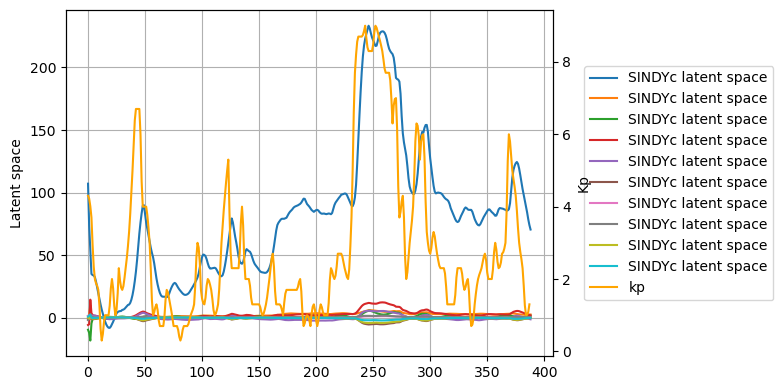

In [ ]:
correction_factor = 1.
T1 = 3600/correction_factor
T2 = 3600/correction_factor
time_conversion_factor = T1/T2 #What was previously called sub_intervals: it is in fact the number of intervals in an hour.

storms_dict = {
    '2003_q': {
        'start_date':datetime.strptime('2003-01-05 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
        'stop_date':datetime.strptime('2003-01-07 23:59:59', '%Y-%m-%d %H:%M:%S')},
    '2003': {
        'start_date':datetime.strptime('2003-10-28 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
        'stop_date':datetime.strptime('2003-11-04 23:59:59', '%Y-%m-%d %H:%M:%S')},
    '2024': {
        'start_date':datetime.strptime('2024-05-01 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
        'stop_date':datetime.strptime('2024-05-16 23:59:59', '%Y-%m-%d %H:%M:%S')},
    '2026': {
        'start_date':datetime.strptime('2026-01-18 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
        'stop_date':datetime.strptime('2026-01-21 23:59:59', '%Y-%m-%d %H:%M:%S')}
                }

start_date = storms_dict['2024']['start_date']
stop_date = storms_dict['2024']['stop_date']
# D:\propagator\fully_discrete\mat_inputs\tiegcm_ddm_20260123d_cls.mat
model_object = sio.loadmat(
    "./mat_inputs/tiegcm_ddm_20260123d_cls.mat",
    squeeze_me=True,
    struct_as_record=False
)
z_dict = {}

frcst_func_sindy, frcst_func_sindy_hourly, u_ds_prop, output_datetimes = pu.propagate(start_date, stop_date, model_object, ar_lags, \
    T1, T2, time_conversion_factor, model_object['n_components'], model_name = 'sindy-c', B_sindy = model_object['B_sindy'], drivers = 'cls')
frcst_func_dmd, frcst_func_dmd_hourly, _, _ = pu.propagate(start_date, stop_date, model_object, ar_lags, \
    T1, T2, time_conversion_factor, model_object['n_components'], model_name = 'dmd-c', B_sindy = model_object['B_sindy'], drivers = 'cls')
z_dict.update({'sindy': frcst_func_sindy, 'dmd': frcst_func_dmd})
datetimes_ds_num = model_object['datetimes_ds']
datetimes_ds = pu.get_propagator_datetimes(datetimes_ds_num)
dates_mask = np.array([(start_date <= date_time <=stop_date) for date_time in datetimes_ds])
fig, axis1 = plt.subplots(figsize=(8, 4))
axis1.plot(frcst_func_sindy_hourly.T, label = 'SINDYc latent space')
# axis1.plot(z_ds[0, dates_mask].T, linestyle = ':', color = 'black', label = 'actual z0')
axis1.set_ylabel('Latent space')

axis2 = plt.twinx()
axis2.plot(u_ds_prop[kp_idx, :], color = 'orange', label = 'kp')
axis2.set_ylabel('Kp')

lines1, labels1 = axis1.get_legend_handles_labels()
lines2, labels2 = axis2.get_legend_handles_labels()
axis1.legend(lines1 + lines2, labels1 + labels2, loc='best')
axis1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5)
)
axis1.grid()
plt.tight_layout()

plt.show()

In [4]:
# correction_factor = 1.
# T1 = 3600/correction_factor
# T2 = 3600/correction_factor
# time_conversion_factor = T1/T2 #What was previously called sub_intervals: it is in fact the number of intervals in an hour.

# storms_dict = {
#     '2003': {
#         'start_date':datetime.strptime('2003-10-28 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
#         'stop_date':datetime.strptime('2003-11-04 23:59:59', '%Y-%m-%d %H:%M:%S')},
#     '2024': {
#         'start_date':datetime.strptime('2024-05-01 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
#         'stop_date':datetime.strptime('2024-05-16 23:59:59', '%Y-%m-%d %H:%M:%S')},
#     '2026': {
#         'start_date':datetime.strptime('2026-01-18 00:00:00', '%Y-%m-%d %H:%M:%S') - timedelta(hours=max(ar_lags)), 
#         'stop_date':datetime.strptime('2026-01-21 23:59:59', '%Y-%m-%d %H:%M:%S')}
#                 }

# start_date = storms_dict['2024']['start_date']
# stop_date = storms_dict['2024']['stop_date']

# model_object = sio.loadmat(
#     "D:/propagator/fully_discrete/mat_inputs/tiegcm_ddm_20260123d_cls.mat",
#     squeeze_me=True,
#     struct_as_record=False
# )
# z_dict = {}

# frcst_func_sindy, frcst_func_sindy_hourly, u_ds_prop, output_datetimes = pu.propagate(start_date, stop_date, model_object, ar_lags, \
#     T1, T2, time_conversion_factor, model_object['n_components'], model_name = 'sindy-c', B_sindy = model_object['B_sindy'], drivers = 'cls')

# z_dict.update({'sindy': frcst_func_sindy})
# datetimes_ds_num = model_object['datetimes_ds']
# datetimes_ds = pu.get_propagator_datetimes(datetimes_ds_num)
# dates_mask = np.array([(start_date <= date_time <=stop_date) for date_time in datetimes_ds])
# fig, axis1 = plt.subplots(figsize=(8, 4))
# axis1.plot(frcst_func_sindy_hourly.T, label = 'SINDYc latent space')
# # axis1.plot(z_ds[0, dates_mask].T, linestyle = ':', color = 'black', label = 'actual z0')
# axis1.set_ylabel('Latent space')

# axis2 = plt.twinx()
# axis2.plot(u_ds_prop[kp_idx, :], color = 'orange', label = 'kp')
# axis2.set_ylabel('Kp')

# lines1, labels1 = axis1.get_legend_handles_labels()
# lines2, labels2 = axis2.get_legend_handles_labels()
# axis1.legend(lines1 + lines2, labels1 + labels2, loc='best')
# axis1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc='center left',
#     bbox_to_anchor=(1.05, 0.5)
# )
# axis1.grid()
# plt.tight_layout()

# plt.show()

In [5]:
satellite_all, satellite_hourly = pu.import_satellite_data('champ')

Picks the trajectory of the CHAMP satellite during the Halloween storm and translates it in time on the desired timeframe.

In [10]:
hs_start_date = storms_dict['2003']['start_date']
hs_stop_date = storms_dict['2003']['stop_date']


propagation_dates = np.copy(datetimes_ds[dates_mask])
propagation_dates10s = pd.date_range(start=propagation_dates.min(), end=propagation_dates.max(), freq='10s')

trajectory_df = pd.DataFrame({'datetime': propagation_dates10s})
trajectory_length = len(trajectory_df)
trajectory_df['lon'] = np.take(satellite_all.loc[(satellite_all.index>=hs_start_date) & (satellite_all.index <=hs_stop_date)].lon.values, np.arange(trajectory_length), mode = 'wrap')
trajectory_df['lat'] = np.take(satellite_all.loc[(satellite_all.index>=hs_start_date) & (satellite_all.index <=hs_stop_date)].lat.values, np.arange(trajectory_length), mode = 'wrap')
trajectory_df['alt'] = np.take(satellite_all.loc[(satellite_all.index>=hs_start_date) & (satellite_all.index <=hs_stop_date)].alt.values/1000., np.arange(trajectory_length), mode = 'wrap')
trajectory_df['lst'] = np.take(satellite_all.loc[(satellite_all.index>=hs_start_date) & (satellite_all.index <=hs_stop_date)].lst.values, np.arange(trajectory_length), mode = 'wrap')
trajectory_df['accelerometer_density'] = np.take(satellite_all.loc[(satellite_all.index>=hs_start_date) & (satellite_all.index <=hs_stop_date)].accelerometer_density.values, np.arange(trajectory_length), mode = 'wrap')

prop_drivers_df = pd.DataFrame(u_ds_prop.T, columns = ['year', 't1', 't2', 't3', 't4', 'f10', 'kp'])
prop_drivers_df['datetime'] = pd.date_range(start = start_date, periods = prop_drivers_df.shape[0], freq = '3600s')

# Ensure datetime columns are real datetimes
prop_drivers_df["datetime"]     = pd.to_datetime(prop_drivers_df["datetime"])

# Sort (required by merge_asof)
drivers_sorted   = prop_drivers_df.sort_values("datetime")

# Merge on closest datetime (keeps satellite 10s resolution)
merged_10s = pd.merge_asof(
    trajectory_df,
    drivers_sorted,
    on="datetime",
    direction="nearest",                 # closest match (can also use "backward" or "forward")
    tolerance=pd.Timedelta("30min")      # optional: avoid matching if too far away
)
# plt.plot(merged_10s.kp.values)

coordinates_np = np.stack([trajectory_df.lat.values, trajectory_df.lst.values, trajectory_df.alt.values], axis = 1)
trajectory_df['predicted_density_sindy'] = pu.interpolate(output_datetimes, np.asarray(trajectory_df.datetime.values[:]), coordinates_np[:].reshape((-1, 3)), model_object, z_dict)[0][:, 0]
trajectory_df['predicted_density_dmd'] = pu.interpolate(output_datetimes, np.asarray(trajectory_df.datetime.values[:]), coordinates_np[:].reshape((-1, 3)), model_object, z_dict)[0][:, 1]
data_to_plot = pd.concat([trajectory_df.drop(columns = ['accelerometer_density']), merged_10s.drop(columns = 'datetime')], axis = 1)
data_to_plot.head()

,datetime,lon,lat,alt,lst,predicted_density_sindy,predicted_density_dmd,lon,lat,alt,lst,accelerometer_density,year,t1,t2,t3,t4,f10,kp
0,2024-04-30 20:00:00.000003,89.962866,-43.307545,405.976452,1.262,3.338813e-12,5.181227e-12,89.962866,-43.307545,405.976452,1.262,2.754927e-12,2024.0,-0.502481,0.864588,0.866025,-0.5,136.402222,4.222222
1,2024-04-30 20:00:10.000003,89.978871,-42.660273,405.691958,1.266,3.355828e-12,5.211961e-12,89.978871,-42.660273,405.691958,1.266,2.789731e-12,2024.0,-0.502481,0.864588,0.866025,-0.5,136.402222,4.222222
2,2024-04-30 20:00:20.000003,89.993694,-42.012861,405.407192,1.270,3.373254e-12,5.242257e-12,89.993694,-42.012861,405.407192,1.270,2.815568e-12,2024.0,-0.502481,0.864588,0.866025,-0.5,136.402222,4.222222
3,2024-04-30 20:00:30.000003,90.007384,-41.365311,405.122269,1.273,3.390992e-12,5.272762e-12,90.007384,-41.365311,405.122269,1.273,2.846740e-12,2024.0,-0.502481,0.864588,0.866025,-0.5,136.402222,4.222222
4,2024-04-30 20:00:40.000003,90.019990,-40.717625,404.837306,1.277,3.408788e-12,5.303232e-12,90.019990,-40.717625,404.837306,1.277,2.881433e-12,2024.0,-0.502481,0.864588,0.866025,-0.5,136.402222,4.222222


In [9]:
pu.interpolate(output_datetimes, np.asarray(trajectory_df.datetime.values[:]), coordinates_np[:].reshape((-1, 3)), model_object, z_dict)[0][:, 0]

array([3.33881338e-12, 3.35582786e-12, 3.37325391e-12, ...,
       4.75645010e-12, 4.79585094e-12, 4.83629896e-12], shape=(139321,))

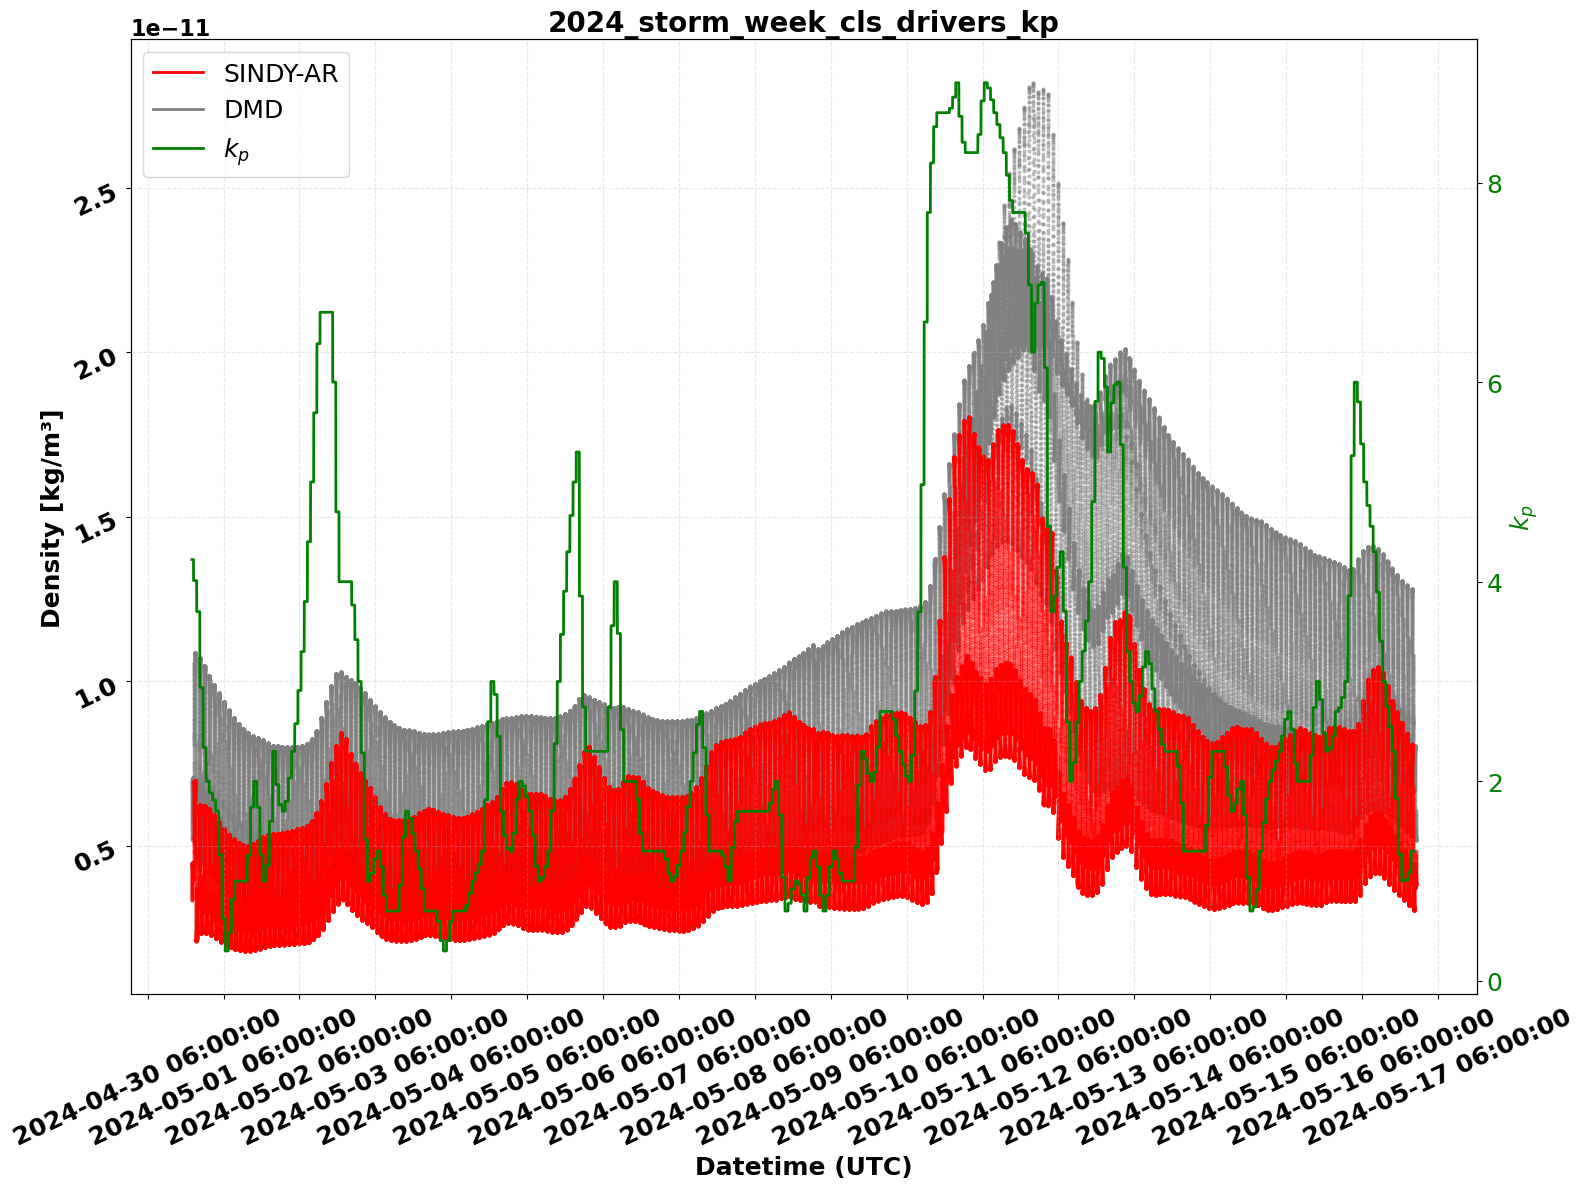

In [14]:
color_sindy = 'red'
color_dmd = 'grey'
color_TIEGCM = 'yellow'
color_grace = 'blue'
color_kp = 'green'
title = '2024_storm_week_cls_drivers_kp'

fig, ax = plt.subplots(1, 1, figsize=(16, 12), sharex=True)

# === Scatter plots for densities ===

ax.scatter(data_to_plot.datetime, data_to_plot['predicted_density_dmd'],
           label='DMD', color=color_dmd, s=4, alpha=0.4)
ax.scatter(data_to_plot.datetime, data_to_plot['predicted_density_sindy'],
           label='AR-SINDY', color=color_sindy, s=4, alpha=0.4)

# === Second y-axis for Kp ===
ax2 = ax.twinx()
ax2.plot(data_to_plot.datetime, data_to_plot['kp'], color=color_kp,
         linewidth=2.0, label=r'$k_{p}$', alpha=1)
ax2.set_ylabel(r'$k_{p}$', color=color_kp, fontsize=18, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_kp, labelsize=18)
ax2.grid(False)

# === Primary axis setup ===
ax.set_title(title, fontsize=20, fontweight='bold')
ax.set_ylabel("Density [kg/m³]", fontsize=18, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)

# === X-axis formatting ===
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='both', labelsize=18)

for axis in [ax]:
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
    for label in axis.get_xticklabels() + axis.get_yticklabels():
        label.set_rotation(25)
        label.set_fontweight('bold')
        label.set_fontsize(18)
    if axis is ax:
        axis.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        axis.yaxis.get_offset_text().set_fontsize(16)
        axis.yaxis.get_offset_text().set_fontweight('bold')

# === Combined legend ===
legend_handles = [
    Line2D([0], [0], color=color_sindy, label='SINDY-AR', linewidth=2),
    Line2D([0], [0], color=color_dmd, label='DMD', linewidth=2),
    Line2D([0], [0], color=color_kp, label=r'$k_{p}$', linewidth=2)
]

ax.legend(handles=legend_handles, loc='upper left', fontsize=18)
ax.set_xlabel("Datetime (UTC)", fontsize=18, fontweight='bold')

plt.tight_layout()
safe_title = re.sub(r'[^\w\s-]', '', title).replace(' ', '_')
# plt.savefig(f'./results/{safe_title}.png', dpi=300, bbox_inches='tight')
plt.show()